# 20 · 이벤트 밀도 × 의도적 행동 분리 가설

**한 줄 답:** 첫 10분 이벤트가 20회 이상인 29대는 다시 둘로 나뉜다. 의도적 행동 6회 이상은 7/18(38.9%)이 후속 행동했고, 의도적 행동 6회 미만도 3/11(27.3%)이 후속 행동했다. 둘 다 버릴 집단은 아니지만, 유도 방식은 달라야 한다.

**가설 H-split:** `early_tracked_events >= 20` 집단 안에서도 실제 의도적 행동이 많은 기기는 새 영역/퀘스트/즐길거리 유도가 맞고, 의도적 행동이 적은 기기는 콘텐츠 추천보다 첫 행동·조작·진입 안내가 먼저다.

**사전 기준:**

- `tracked>=20 & deliberate>=6`의 후속 행동률이 `<20` 집단보다 +15%p 이상 높으면 “즐길거리 유도 후보”
- `tracked>=20 & deliberate<6`의 후속 행동률이 `<20` 집단보다 +10%p 이상 높으면 “진입/첫 행동 안내 후보”
- 각 고밀도 세그먼트의 n이 10 미만이면 보류

**금지선:** A/B 효과를 보지 않는다. 10분 이후 컬럼은 타깃/해석에만 쓰고 피처로 쓰지 않는다. 운영 배포나 계수 교체는 하지 않는다.

## 1. 코드와 데이터

입력은 17번 전체 채널 후보표다. 한 행은 익명 신규 기기 하나다.

In [1]:
from pathlib import Path
import json
import os, sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parents[1]
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'ml'))

from calm_ml import report as R

R.setup()
SRC = ROOT / 'ml/reports/g3_all_channel_later_targets_2026-09-15/all_channel_later_target_candidates.csv'
OUT = ROOT / 'ml/reports/g5_event_density_action_split_2026-09-15'
OUT.mkdir(parents=True, exist_ok=True)

TRACKED_THRESHOLD = 20
DELIBERATE_THRESHOLD = 6

def wilson(k, n, z=1.96):
    if n == 0:
        return 0, 0
    p = k / n
    den = 1 + z * z / n
    center = (p + z * z / (2 * n)) / den
    half = z * ((p * (1 - p) / n + z * z / (4 * n * n)) ** 0.5) / den
    return center - half, center + half

def bootstrap_diff_ci(a, b, n_boot=10000, seed=20):
    rng = np.random.default_rng(seed)
    vals = []
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    for _ in range(n_boot):
        vals.append(rng.choice(a, size=len(a), replace=True).mean() - rng.choice(b, size=len(b), replace=True).mean())
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))


## 2. 세그먼트 만들기

`tracked>=20`은 19번에서 확정 킵한 이벤트 밀도 신호다. 여기서는 그 안을 의도적 행동 6회 기준으로 다시 나눈다.

In [2]:
d = pd.read_csv(SRC)
assert d.device_label.is_unique
assert len(d) == 95
assert int(d.later_active.astype(bool).sum()) == 12

d['y'] = d.later_active.astype(bool).astype(int)
d['tracked_high'] = d.early_tracked_events >= TRACKED_THRESHOLD
d['deliberate_high'] = d.early_actions >= DELIBERATE_THRESHOLD

def segment(row):
    if row.tracked_high and row.deliberate_high:
        return '고밀도+의도행동 많음'
    if row.tracked_high and not row.deliberate_high:
        return '고밀도+의도행동 적음'
    if not row.tracked_high and row.early_actions > 0:
        return '저밀도+의도행동 있음'
    return '저밀도+의도행동 없음'

d['split_segment'] = d.apply(segment, axis=1)
d['guidance_candidate'] = np.select(
    [
        d.split_segment.eq('고밀도+의도행동 많음'),
        d.split_segment.eq('고밀도+의도행동 적음'),
    ],
    [
        '새 영역·퀘스트·즐길거리 유도 후보',
        '첫 행동·조작·진입 안내 후보',
    ],
    default='우선 진입/관찰 후보',
)
display(d[['device_label', 'channel_segment', 'early_tracked_events', 'early_actions', 'split_segment', 'guidance_candidate', 'later_active']].head(12))


,device_label,channel_segment,early_tracked_events,early_actions,split_segment,guidance_candidate,later_active
0,D001,토스 관측,184,111,고밀도+의도행동 많음,새 영역·퀘스트·즐길거리 유도 후보,True
1,D002,메인·웹만,41,7,고밀도+의도행동 많음,새 영역·퀘스트·즐길거리 유도 후보,True
2,D003,메인·웹만,4,0,저밀도+의도행동 없음,우선 진입/관찰 후보,False
3,D004,메인·웹만,4,0,저밀도+의도행동 없음,우선 진입/관찰 후보,False
4,D005,메인·웹만,3,0,저밀도+의도행동 없음,우선 진입/관찰 후보,False
5,D006,토스 관측,7,0,저밀도+의도행동 없음,우선 진입/관찰 후보,False
6,D007,메인·웹만,5,0,저밀도+의도행동 없음,우선 진입/관찰 후보,False
7,D008,토스 관측,230,100,고밀도+의도행동 많음,새 영역·퀘스트·즐길거리 유도 후보,True
8,D009,토스 관측,165,88,고밀도+의도행동 많음,새 영역·퀘스트·즐길거리 유도 후보,True
9,D010,메인·웹만,5,0,저밀도+의도행동 없음,우선 진입/관찰 후보,False


## 3. 후속 행동률

네 집단의 기기 수와 후속 행동 양성을 비교한다. 작은 집단은 순위로 읽지 않는다.

In [3]:
seg = d.groupby('split_segment', as_index=False).agg(
    devices=('device_label', 'size'),
    positives=('y', 'sum'),
    new_area=('later_new_area', 'sum'),
    quest_social=('later_quest_social', 'sum'),
    fishing_sea=('later_fishing_sea', 'sum'),
    nature=('later_nature', 'sum'),
)
seg['rate'] = seg.positives / seg.devices
seg[['ci_low', 'ci_high']] = [wilson(int(k), int(n)) for k, n in zip(seg.positives, seg.devices)]
order = ['저밀도+의도행동 없음', '저밀도+의도행동 있음', '고밀도+의도행동 적음', '고밀도+의도행동 많음']
seg['order'] = seg.split_segment.map({v: i for i, v in enumerate(order)})
seg = seg.sort_values('order').drop(columns='order')
seg.to_csv(OUT / 'split_segment_summary.csv', index=False)
display(seg)

base = d[~d.tracked_high].y
high_many = d[d.split_segment.eq('고밀도+의도행동 많음')].y
high_few = d[d.split_segment.eq('고밀도+의도행동 적음')].y
diff_many = high_many.mean() - base.mean()
diff_few = high_few.mean() - base.mean()
many_ci = bootstrap_diff_ci(high_many, base)
few_ci = bootstrap_diff_ci(high_few, base)

verdict_many = '즐길거리 유도 후보' if len(high_many) >= 10 and diff_many >= 0.15 else '보류'
verdict_few = '첫 행동·진입 안내 후보' if len(high_few) >= 10 and diff_few >= 0.10 else '보류'

result = pd.DataFrame({
    '검증': ['고밀도+의도행동 많음 vs 저밀도', '고밀도+의도행동 적음 vs 저밀도'],
    '차이': [diff_many, diff_few],
    'bootstrap_95_하한': [many_ci[0], few_ci[0]],
    'bootstrap_95_상한': [many_ci[1], few_ci[1]],
    '판정': [verdict_many, verdict_few],
})
result.to_csv(OUT / 'hypothesis_split_result.csv', index=False)
display(result)


,split_segment,devices,positives,new_area,quest_social,fishing_sea,nature,rate,ci_low,ci_high
2,저밀도+의도행동 없음,64,2,2,1,0,0,0.031250,0.008612,0.106975
3,저밀도+의도행동 있음,2,0,0,0,0,0,0.000000,0.000000,0.657628
1,고밀도+의도행동 적음,11,3,3,1,2,0,0.272727,0.097459,0.565650
0,고밀도+의도행동 많음,18,7,4,7,6,7,0.388889,0.203050,0.613813


,검증,차이,bootstrap_95_하한,bootstrap_95_상한,판정
0,고밀도+의도행동 많음 vs 저밀도,0.358586,0.136364,0.595960,즐길거리 유도 후보
1,고밀도+의도행동 적음 vs 저밀도,0.242424,-0.015152,0.530303,첫 행동·진입 안내 후보


g5_event_density_action_split_rates.png  1105x631px


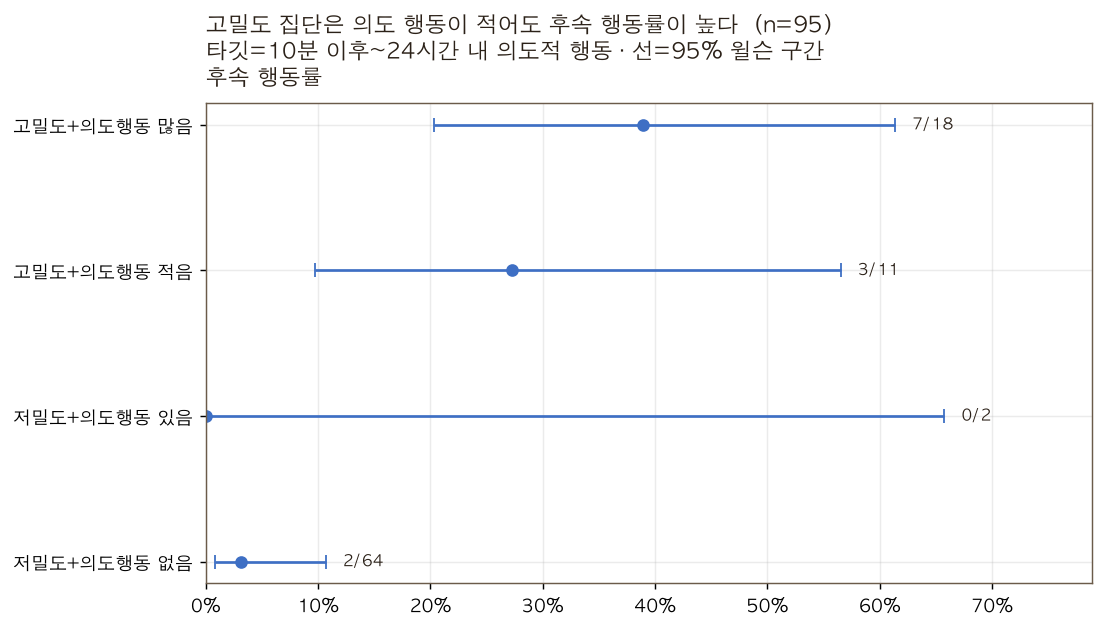

In [4]:
plot = seg.copy()
fig, ax = R.new(
    '고밀도 집단은 의도 행동이 적어도 후속 행동률이 높다',
    len(d),
    sub='타깃=10분 이후~24시간 내 의도적 행동 · 선=95% 윌슨 구간',
    ylab='후속 행동률',
    figsize=(8.8, 4.8),
)
ypos = range(len(plot))
ax.errorbar(
    plot.rate,
    list(ypos),
    xerr=[plot.rate - plot.ci_low, plot.ci_high - plot.rate],
    fmt='o',
    color=R.PALETTE[1],
    capsize=4,
)
ax.set_yticks(list(ypos), plot.split_segment)
ax.set_xlim(0, min(1, max(plot.ci_high) * 1.2))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1))
for i, row in enumerate(plot.itertuples()):
    ax.text(row.ci_high + 0.015, i, f'{int(row.positives)}/{int(row.devices)}', va='center', fontsize=9)
chart_seg = R.save(fig, ax, 'g5_event_density_action_split_rates', zero_base=False)
print(R.check(chart_seg))
display(R.show(chart_seg))


## 4. 후속 목표가 어떻게 다른가

고밀도 두 집단은 둘 다 후속 행동률이 높지만, 무엇을 유도할지는 다를 수 있다. 여기서는 새 영역·퀘스트·낚시 도달을 같이 본다.

In [5]:
target_cols = [
    ('후속 행동', 'later_active'),
    ('새 영역', 'later_new_area'),
    ('퀘스트·교류', 'later_quest_social'),
    ('낚시·바다', 'later_fishing_sea'),
    ('자연·채집', 'later_nature'),
]
target_rows = []
for segment_name, g in d[d.tracked_high].groupby('split_segment'):
    for label, col in target_cols:
        target_rows.append({
            'split_segment': segment_name,
            'target': label,
            'devices': len(g),
            'positives': int(g[col].astype(bool).sum()),
            'rate': float(g[col].astype(bool).mean()),
        })
targets = pd.DataFrame(target_rows)
targets.to_csv(OUT / 'high_density_target_mix.csv', index=False)
display(targets)


,split_segment,target,devices,positives,rate
0,고밀도+의도행동 많음,후속 행동,18,7,0.388889
1,고밀도+의도행동 많음,새 영역,18,4,0.222222
2,고밀도+의도행동 많음,퀘스트·교류,18,7,0.388889
3,고밀도+의도행동 많음,낚시·바다,18,6,0.333333
4,고밀도+의도행동 많음,자연·채집,18,7,0.388889
5,고밀도+의도행동 적음,후속 행동,11,3,0.272727
6,고밀도+의도행동 적음,새 영역,11,3,0.272727
7,고밀도+의도행동 적음,퀘스트·교류,11,1,0.090909
8,고밀도+의도행동 적음,낚시·바다,11,2,0.181818
9,고밀도+의도행동 적음,자연·채집,11,0,0.000000


g5_event_density_action_target_mix.png  999x631px


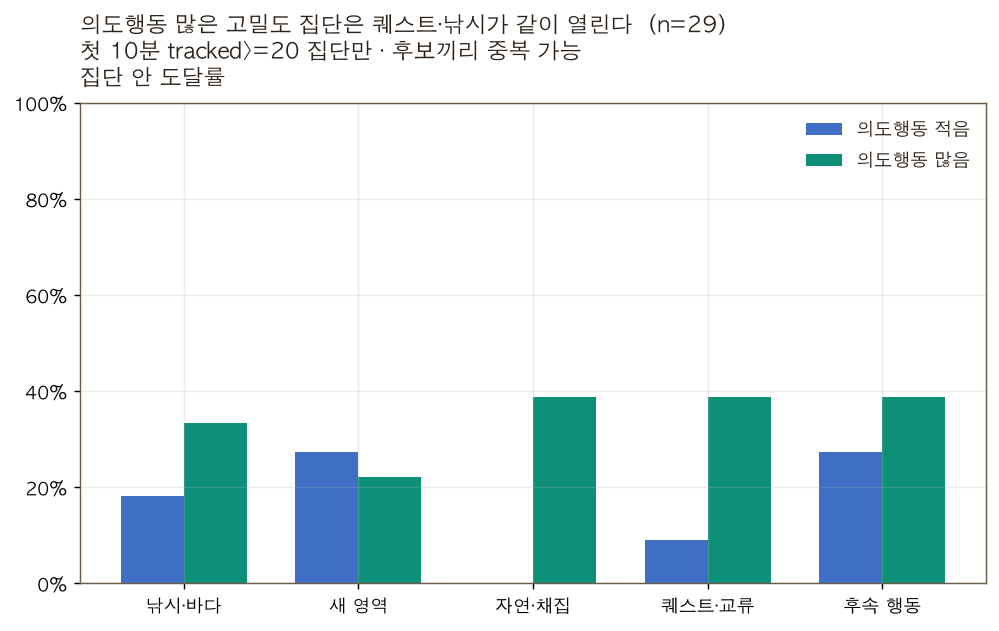

In [6]:
pivot = targets.pivot(index='target', columns='split_segment', values='rate').fillna(0)
pivot = pivot[['고밀도+의도행동 적음', '고밀도+의도행동 많음']]
fig, ax = R.new(
    '의도행동 많은 고밀도 집단은 퀘스트·낚시가 같이 열린다',
    int(d.tracked_high.sum()),
    sub='첫 10분 tracked>=20 집단만 · 후보끼리 중복 가능',
    ylab='집단 안 도달률',
    figsize=(9, 4.8),
)
x = np.arange(len(pivot.index))
width = 0.36
ax.bar(x - width / 2, pivot['고밀도+의도행동 적음'], width, color=R.PALETTE[1], label='의도행동 적음')
ax.bar(x + width / 2, pivot['고밀도+의도행동 많음'], width, color=R.PALETTE[2], label='의도행동 많음')
ax.set_xticks(x, pivot.index)
ax.set_ylim(0, 1.0)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.legend(frameon=False)
chart_mix = R.save(fig, ax, 'g5_event_density_action_target_mix', zero_base=False)
print(R.check(chart_mix))
display(R.show(chart_mix))


## 5. 채널·날짜 점검

고밀도+의도행동 적음 집단이 특정 채널이나 날짜에만 몰리는지 확인한다. 셀 크기가 작으므로 해석은 조심한다.

In [7]:
channel = d.groupby(['channel_segment', 'split_segment'], as_index=False).agg(
    devices=('device_label', 'size'),
    positives=('y', 'sum'),
)
channel['rate'] = channel.positives / channel.devices
channel.to_csv(OUT / 'channel_split_segments.csv', index=False)

day = d.groupby(['first_day', 'split_segment'], as_index=False).agg(
    devices=('device_label', 'size'),
    positives=('y', 'sum'),
)
day['rate'] = day.positives / day.devices
day.to_csv(OUT / 'day_split_segments.csv', index=False)
display(channel)
display(day)


,channel_segment,split_segment,devices,positives,rate
0,메인·웹만,고밀도+의도행동 많음,1,1,1.000000
1,메인·웹만,고밀도+의도행동 적음,3,2,0.666667
2,메인·웹만,저밀도+의도행동 없음,45,1,0.022222
3,토스 관측,고밀도+의도행동 많음,17,6,0.352941
4,토스 관측,고밀도+의도행동 적음,8,1,0.125000
5,토스 관측,저밀도+의도행동 없음,19,1,0.052632
6,토스 관측,저밀도+의도행동 있음,2,0,0.000000


,first_day,split_segment,devices,positives,rate
0,2026-09-04,고밀도+의도행동 많음,5,3,0.600000
1,2026-09-04,고밀도+의도행동 적음,5,2,0.400000
2,2026-09-04,저밀도+의도행동 없음,19,1,0.052632
3,2026-09-04,저밀도+의도행동 있음,1,0,0.000000
4,2026-09-05,고밀도+의도행동 많음,3,2,0.666667
5,2026-09-05,고밀도+의도행동 적음,3,0,0.000000
6,2026-09-05,저밀도+의도행동 없음,6,1,0.166667
7,2026-09-05,저밀도+의도행동 있음,1,0,0.000000
8,2026-09-06,고밀도+의도행동 많음,2,0,0.000000
9,2026-09-06,저밀도+의도행동 없음,2,0,0.000000


g5_event_density_action_channel_check.png  1246x631px


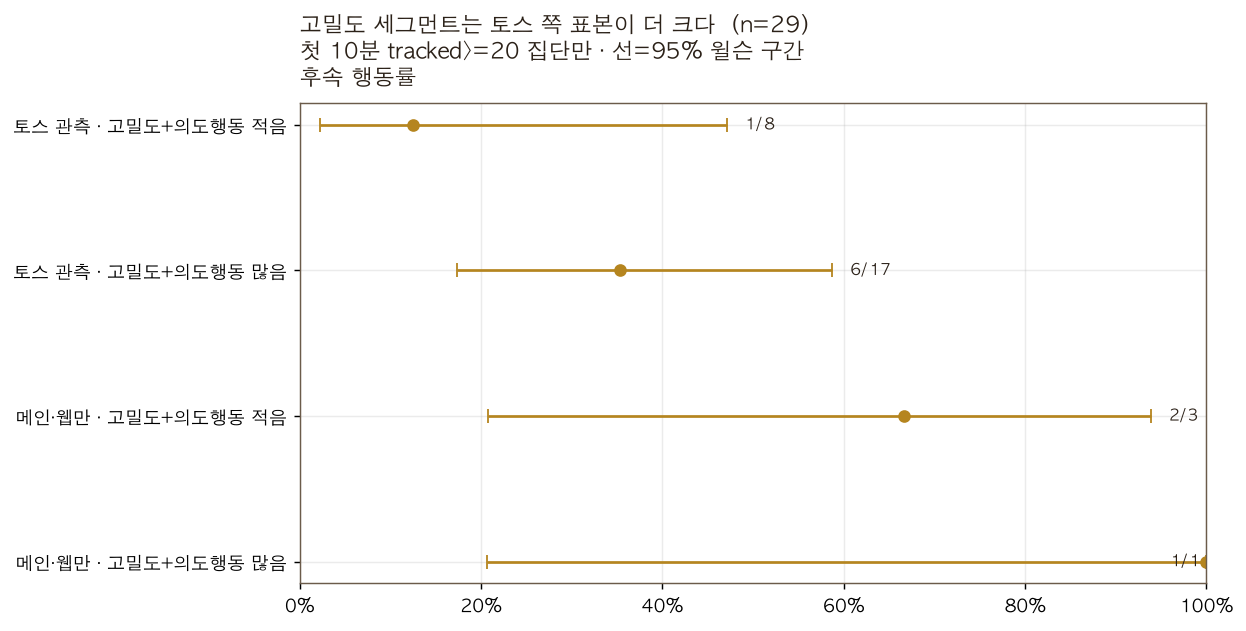

In [8]:
plot = channel[channel.split_segment.isin(['고밀도+의도행동 적음', '고밀도+의도행동 많음'])].copy()
plot['label'] = plot.channel_segment + ' · ' + plot.split_segment
plot[['ci_low', 'ci_high']] = [wilson(int(k), int(n)) for k, n in zip(plot.positives, plot.devices)]
plot = plot.sort_values(['channel_segment', 'split_segment'])

fig, ax = R.new(
    '고밀도 세그먼트는 토스 쪽 표본이 더 크다',
    int(d.tracked_high.sum()),
    sub='첫 10분 tracked>=20 집단만 · 선=95% 윌슨 구간',
    ylab='후속 행동률',
    figsize=(9, 4.8),
)
ypos = range(len(plot))
ax.errorbar(
    plot.rate,
    list(ypos),
    xerr=[plot.rate - plot.ci_low, plot.ci_high - plot.rate],
    fmt='o',
    color=R.PALETTE[3],
    capsize=4,
)
ax.set_yticks(list(ypos), plot.label)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1))
for i, row in enumerate(plot.itertuples()):
    ax.text(min(row.ci_high + 0.02, 0.96), i, f'{int(row.positives)}/{int(row.devices)}', va='center', fontsize=9)
chart_channel = R.save(fig, ax, 'g5_event_density_action_channel_check', zero_base=False)
print(R.check(chart_channel))
display(R.show(chart_channel))


## 6. 제품 해석

`고밀도+의도행동 많음`은 첫 10분 안에 이미 게임 행동으로 들어온 집단이다. 이들에게는 새 영역, 퀘스트, 낚시 같은 “다음 할거리”를 보여주는 쪽이 자연스럽다.

`고밀도+의도행동 적음`은 이벤트는 많이 찍혔지만 실제 행동은 적은 집단이다. 그래도 후속 행동률이 3/11로 낮지 않다. 이들은 버릴 집단이 아니라, 첫 행동 안내·조작 안내·진입 흐름 개선의 후보로 보는 쪽이 맞다.

`저밀도+의도행동 없음`은 64대 중 2대만 후속 행동했다. 여기는 콘텐츠 추천보다 진입 전환 문제를 먼저 의심한다.

## 7. 이 숫자로 말할 수 없는 것

- `early_tracked_events`에는 자동 이벤트도 섞인다. “관심”과 “계측 밀도”가 완전히 분리된 값은 아니다.
- 고밀도+의도행동 적음 집단은 11대다. 제품 규칙을 바로 확정하기엔 작다.
- 메인·웹 고밀도 셀은 4대뿐이다. 채널 간 우열은 말하지 않는다.
- 시설 확장 이후 코호트가 들어오면 이 분기가 유지되는지 다시 봐야 한다.

In [9]:
audit = {
    'analysis': 'g5-event-density-action-split-hypothesis',
    'date': '2026-09-15',
    'source': str(SRC),
    'hypothesis': 'Within early_tracked_events >= 20, deliberate action depth separates next-content guidance from first-action guidance candidates.',
    'thresholds': {
        'early_tracked_events': TRACKED_THRESHOLD,
        'early_actions': DELIBERATE_THRESHOLD,
    },
    'n': int(len(d)),
    'positives': int(d.y.sum()),
    'segments': seg.drop(columns=['ci_low', 'ci_high']).to_dict(orient='records'),
    'tests': result.to_dict(orient='records'),
    'verdict': {
        'high_tracked_high_deliberate': verdict_many,
        'high_tracked_low_deliberate': verdict_few,
    },
    'constraints': [
        'not an A/B read',
        'no production deployment',
        'device-level, not person-level',
        'post-10-minute fields used only as labels and interpretation targets',
    ],
}
(OUT / 'hypothesis_audit.json').write_text(json.dumps(audit, ensure_ascii=False, indent=2), encoding='utf-8')
display(Markdown('```json\n' + json.dumps(audit, ensure_ascii=False, indent=2) + '\n```'))


```json
{
  "analysis": "g5-event-density-action-split-hypothesis",
  "date": "2026-09-15",
  "source": "/Users/uicheol_hwang/calm_forest/ml/reports/g3_all_channel_later_targets_2026-09-15/all_channel_later_target_candidates.csv",
  "hypothesis": "Within early_tracked_events >= 20, deliberate action depth separates next-content guidance from first-action guidance candidates.",
  "thresholds": {
    "early_tracked_events": 20,
    "early_actions": 6
  },
  "n": 95,
  "positives": 12,
  "segments": [
    {
      "split_segment": "저밀도+의도행동 없음",
      "devices": 64,
      "positives": 2,
      "new_area": 2,
      "quest_social": 1,
      "fishing_sea": 0,
      "nature": 0,
      "rate": 0.03125
    },
    {
      "split_segment": "저밀도+의도행동 있음",
      "devices": 2,
      "positives": 0,
      "new_area": 0,
      "quest_social": 0,
      "fishing_sea": 0,
      "nature": 0,
      "rate": 0.0
    },
    {
      "split_segment": "고밀도+의도행동 적음",
      "devices": 11,
      "positives": 3,
      "new_area": 3,
      "quest_social": 1,
      "fishing_sea": 2,
      "nature": 0,
      "rate": 0.2727272727272727
    },
    {
      "split_segment": "고밀도+의도행동 많음",
      "devices": 18,
      "positives": 7,
      "new_area": 4,
      "quest_social": 7,
      "fishing_sea": 6,
      "nature": 7,
      "rate": 0.3888888888888889
    }
  ],
  "tests": [
    {
      "검증": "고밀도+의도행동 많음 vs 저밀도",
      "차이": 0.35858585858585856,
      "bootstrap_95_하한": 0.13636363636363635,
      "bootstrap_95_상한": 0.595959595959596,
      "판정": "즐길거리 유도 후보"
    },
    {
      "검증": "고밀도+의도행동 적음 vs 저밀도",
      "차이": 0.2424242424242424,
      "bootstrap_95_하한": -0.015151515151515152,
      "bootstrap_95_상한": 0.5303030303030303,
      "판정": "첫 행동·진입 안내 후보"
    }
  ],
  "verdict": {
    "high_tracked_high_deliberate": "즐길거리 유도 후보",
    "high_tracked_low_deliberate": "첫 행동·진입 안내 후보"
  },
  "constraints": [
    "not an A/B read",
    "no production deployment",
    "device-level, not person-level",
    "post-10-minute fields used only as labels and interpretation targets"
  ]
}
```

## 8. 판정

**H-split는 채택 후보.** 고밀도 집단은 의도적 행동이 많든 적든 저밀도 집단보다 후속 행동률이 높다. 다만 개입 메시지는 나눠야 한다. 의도행동 많음은 다음 콘텐츠, 의도행동 적음은 첫 행동·진입 안내가 더 맞다. 여기서 멈춘다.